# BunDLeNet to ConitiveGraphs

In [41]:
%load_ext autoreload
%autoreload 2
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.ensemble import RandomForestClassifier
from IPython.display import HTML

try: from ncmcm.data_loaders.matlab_dataset import Database
except ImportError: sys.path.append("..")
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model, project_into_latent_space
from ncmcm.bundlenet.utils import prep_data
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser
from ncmcm.cognitive_graphs.cognitive_graphs import behavioral_state_diagram
from ncmcm.cognitive_graphs.cognitive_graphs import cluster_neural_activity
from ncmcm.statistical_testing.markov import markov_property_test

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## BunDLeNet
### Load C. elegans Neuronal Data (excluding behavioural neurons)

In [3]:
worm_num = 0
algorithm = 'BunDLe-Net'
b_neurons = [
    'AVAR',
    'AVAL',
    'SMDVR',
    'SMDVL',
    'SMDDR',
    'SMDDL',
    'RIBR',
    'RIBL'
]
data_path = '../datasets/raw/c_elegans/NoStim_Data.mat'
data = Database(data_path=data_path, dataset_no=worm_num)
data.exclude_neurons(b_neurons)
x = data.neuron_traces.T
b = data.behaviour
behaviors = list(data.behaviour_names.values())

### Visualise Neuronal and Behavioural data

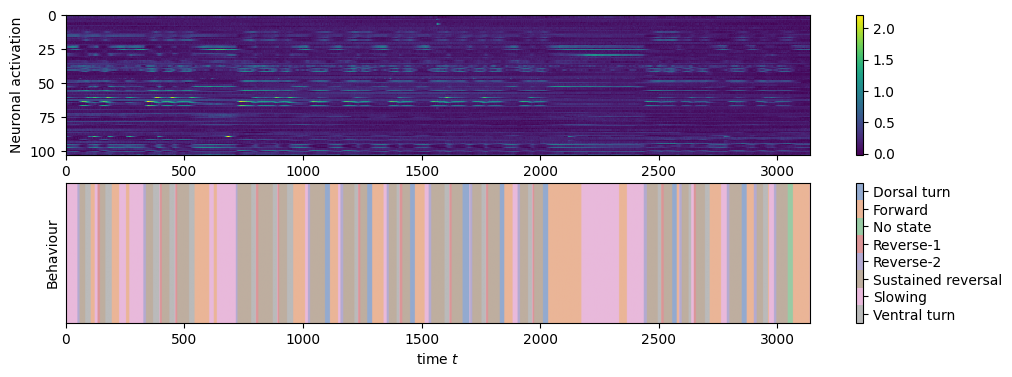

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: xlabel='time $t$', ylabel='Neuronal activation'>,
        <Axes: xlabel='time $t$', ylabel='Behaviour'>], dtype=object))

In [15]:
plotting_neuronal_behavioural(x, b, b_names=data.behaviour_names)

### Train BunDLeNet

In [9]:
x_, b_ = prep_data(x, b, win=15) # prepare data for BunDLe Net

# train BunDLeNet
model = BunDLeNet(latent_dim=3, num_behaviour=len(data.behaviour_names), input_shape=x_.shape)
loss_array, _ = train_model(
    x_,
    b_,
    model,
    b_type='discrete',
    gamma=0.9,
    learning_rate=0.001,
    n_epochs=1000
)

Loss [Markov, Behaviour, Total]: [0.0074 0.0037 0.0111]: 100%|█| 1000/1000 [04


### Training loss versus epochs

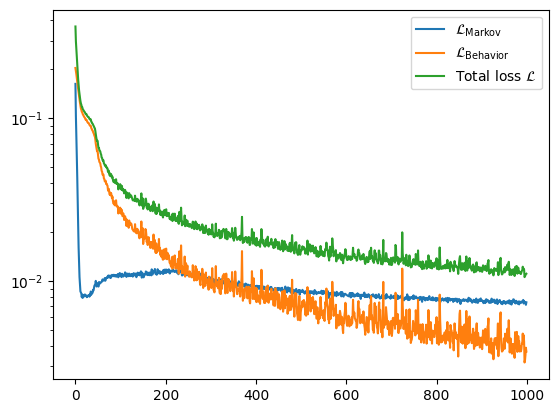

In [10]:
for i, label in enumerate([
    r"$\mathcal{L}_{\mathrm{Markov}}$",
    r"$\mathcal{L}_{\mathrm{Behavior}}$",
    r"Total loss $\mathcal{L}$"
]):
    plt.semilogy(loss_array[:, i], label=label)
plt.legend()
plt.show()

### Visualising embedding

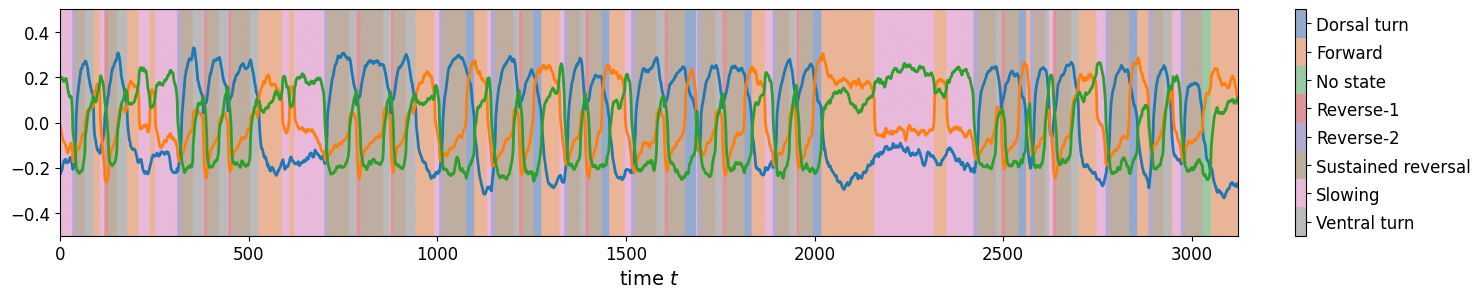

In [35]:
# projecting into latent space
y0_ = project_into_latent_space(x_, model)

# Plotting latent space dynamics
vis = LatentSpaceVisualiser(y0_, b_, data.behaviour_names)
vis.plot_latent_timeseries(filename=f'../figures/latent_time_series_{algorithm}_worm_{worm_num}.png')

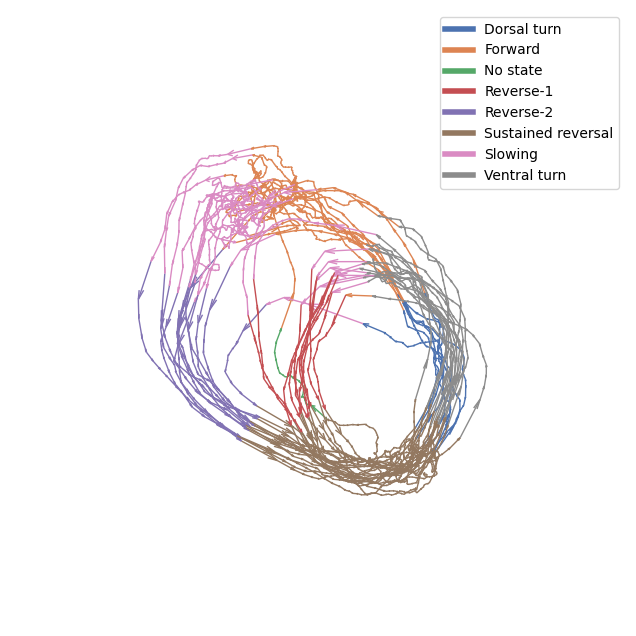

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [17]:
vis.plot_phase_space(filename = f'../figures/phase_space_dynamics_{algorithm}_worm_{worm_num}.png', arrow_length_ratio=0.25)

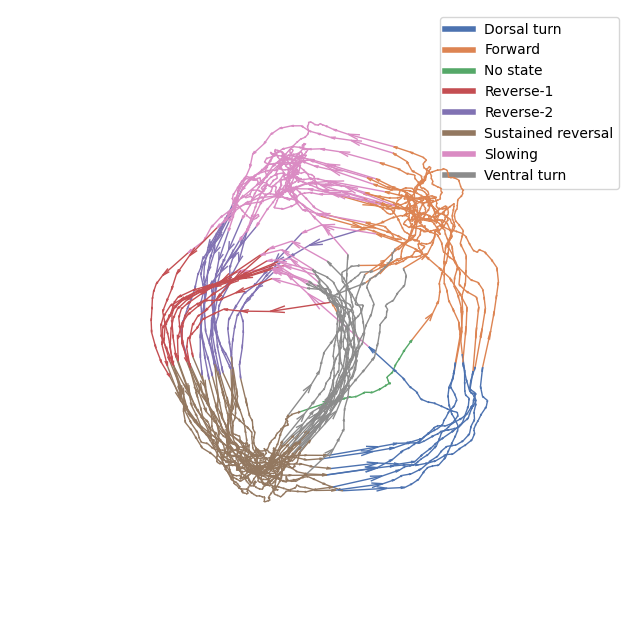

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [18]:
vis.rotating_plot(filename=f'../figures/rotation_{algorithm}_worm_{worm_num}.gif', arrow_length_ratio=0.25)

### Recurrence plot analysis of BunDLeNet's embedding

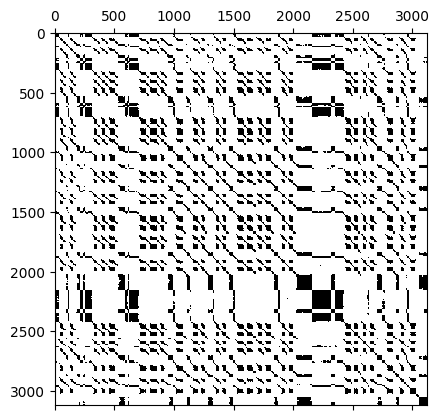

In [19]:
pd_y = np.linalg.norm(y0_[:, np.newaxis] - y0_, axis=-1) < 0.8
plt.matshow(pd_y, cmap='Greys')
plt.show()

## Cognitive state sequence by clustering behavioral probability trajectories (BPT)

In [25]:
p, _ = markov_property_test(b, simulations=250)
print(f"p-value: {p:.3f}")

p-value: 0.032


We get a low (< 0.05) p-value which indicates that the sequence of behaviors does not seem to follow a Markov process of the 1st order.

This next method cluster_neural_activity allows for a lot of customizability, with only the first 3 parameters being required. For 'model' parameter, a classifier with the methods; predict, predict_proba and fit works fine.


### Obtain cognitive states with raw neuronal activity data

Accuracy for full training data: 0.9993624481989162
Testing markovianity for 3 clusters - repetition 1
Testing markovianity for 3 clusters - repetition 2
Testing markovianity for 3 clusters - repetition 3
Testing markovianity for 3 clusters - repetition 4
Testing markovianity for 3 clusters - repetition 5
Testing markovianity for 3 clusters - repetition 6
Testing markovianity for 3 clusters - repetition 7
Testing markovianity for 3 clusters - repetition 8
Testing markovianity for 3 clusters - repetition 9
Testing markovianity for 3 clusters - repetition 10
(10, 3)


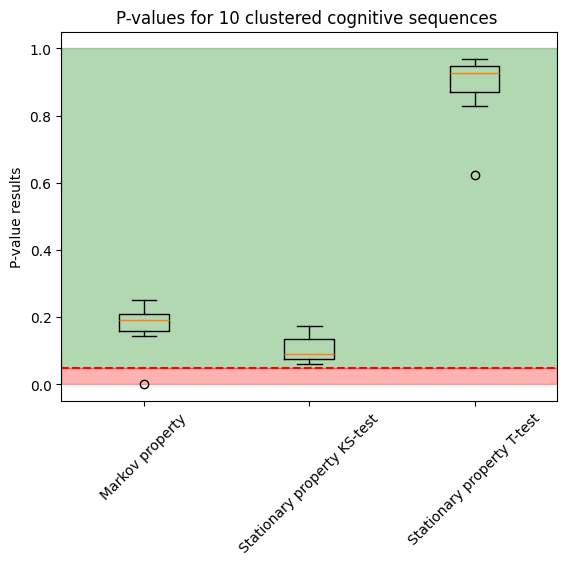

In [26]:
cognitive_states_r = cluster_neural_activity(
    N=x.T, 
    B=b.astype(int),
    n_clusters=3,
    nrep=10,
    ensemble=True,
    sim_m=200,
    sim_s='optimal',
    chunks=None,
    clustering='kmeans',
    kmeans_init='auto',
    test_mode='both',
    test_stationary_property=True,
    model=RandomForestClassifier(n_estimators=20, random_state=42), # we use a RandomForest
    plot=True
)

The plot above shows the distributions of the p-values of the statistical tests for each of the simulated cognitive state sequences.

The method sorts the cognitive state sequence simulations according to the 'best' p-values.
Entries with p-values signaling no violations against the Markov property are listed first.

#### Each tuple in the list contains: 
- the sequence;
- p-value markov property;
- p-value stationary property ks-test (optional);
- p-value stationary property t-test (optional);


### Obtain cognitive states with the embedding

Accuracy for full training data: 0.9990390775144138
Testing markovianity for 3 clusters - repetition 1
Testing markovianity for 3 clusters - repetition 2
Testing markovianity for 3 clusters - repetition 3
Testing markovianity for 3 clusters - repetition 4
Testing markovianity for 3 clusters - repetition 5
Testing markovianity for 3 clusters - repetition 6
Testing markovianity for 3 clusters - repetition 7
Testing markovianity for 3 clusters - repetition 8
Testing markovianity for 3 clusters - repetition 9
Testing markovianity for 3 clusters - repetition 10
(10, 3)


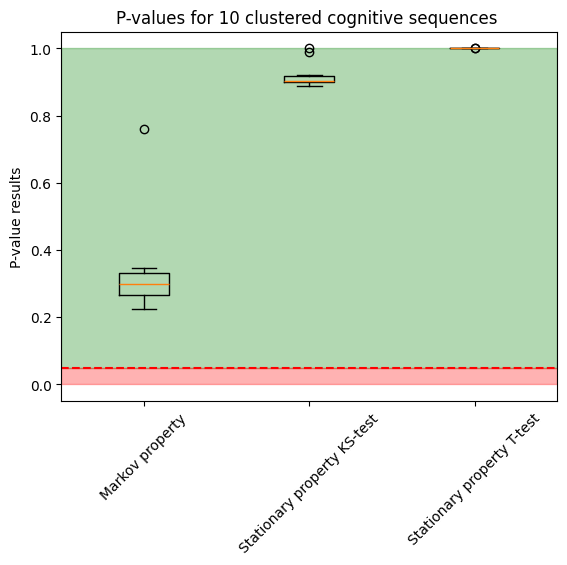

In [29]:
cognitive_states_e = cluster_neural_activity(
    N=y0_.T,
    B=b_.astype(int),
    n_clusters=3,
    nrep=10,
    ensemble=True,
    sim_m=200,
    sim_s='optimal',
    chunks=None,
    clustering='kmeans',
    kmeans_init='auto',
    test_mode='both',
    test_stationary_property=True,
    model=RandomForestClassifier(n_estimators=20, random_state=42),
    plot=True
)

### Markov and stationary properties of the best result

In [30]:
best_result_r = cognitive_states_r[0]
best_sequence_r = best_result_r[0]
best_result_e = cognitive_states_e[0]
best_sequence_e = best_result_e[0]
print(best_result_r[1:], best_result_e[1:])

(0.25, 0.1281493637327944, 0.949329665799189) (0.76, 1.0, 1.0)


The result for the sequence with the most promising result (cognitive state sequence) is printed above. The Markov property and the stationary property do indicate that no evidence disrespecting both rules was found. The cognitive sequence could therefore be stemming from a Markov process 1st order.

### Plot the cognitive graphs

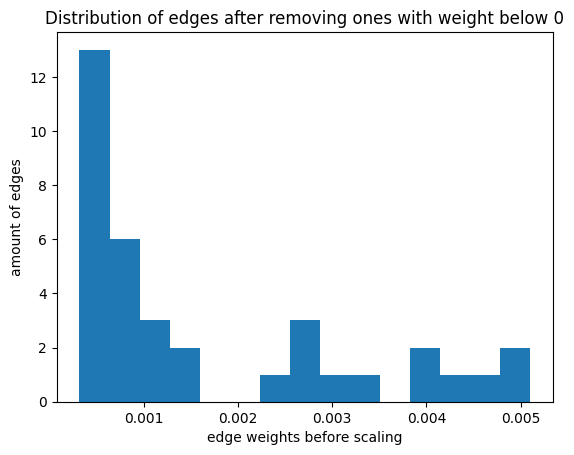

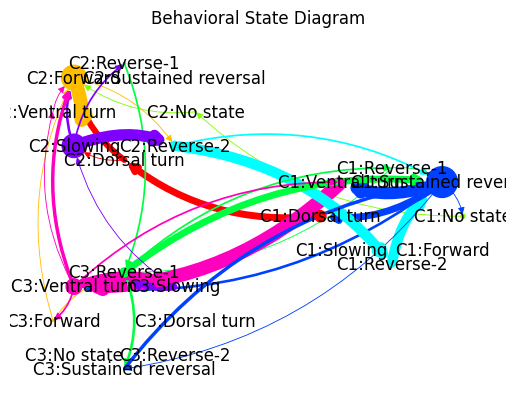

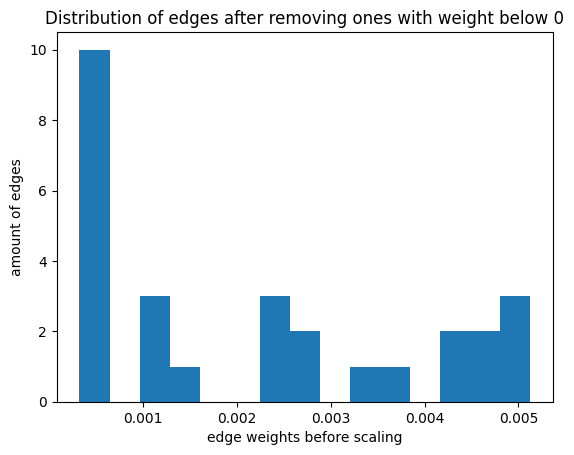

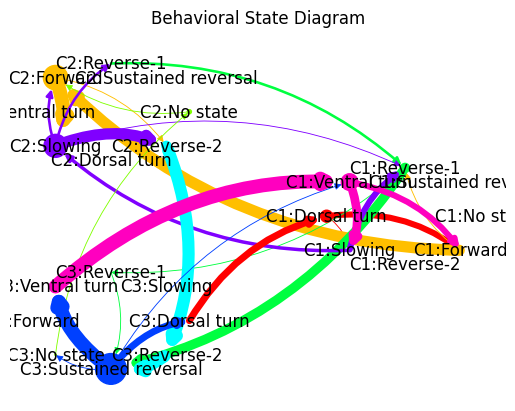

In [43]:
behavioral_state_diagram(
    best_sequence_r, b, behaviors=behaviors,
    weights_hist=True,
    bins=15,
    threshold=0
)
behavioral_state_diagram(
    best_sequence_e, b_, behaviors=behaviors,
    weights_hist=True,
    bins=15,
    threshold=0
)
%matplotlib inline

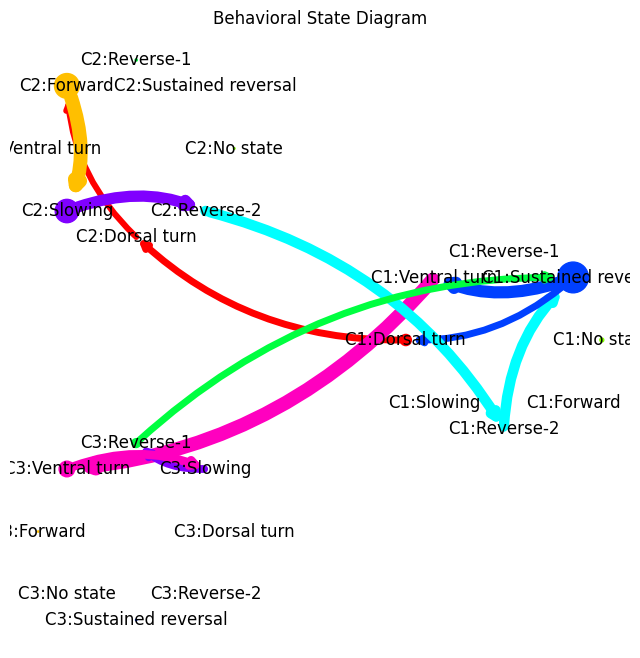

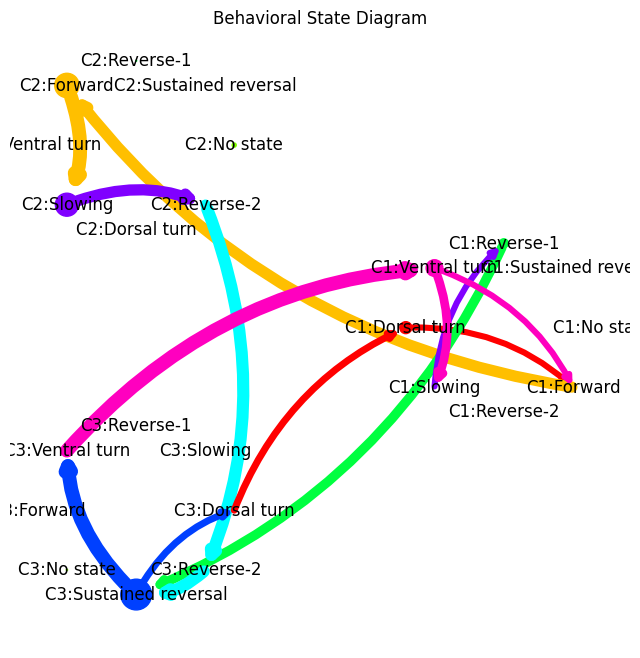

True

In [44]:
behavioral_state_diagram(
    best_sequence_r, b,
    behaviors=behaviors,
    threshold=0.002,
    figsize=(8, 8)
)
behavioral_state_diagram(
    best_sequence_e, b_,
    behaviors=behaviors,
    threshold=0.002,
    figsize=(8, 8)
)

Calculated threshold is:  0.000510204081632653


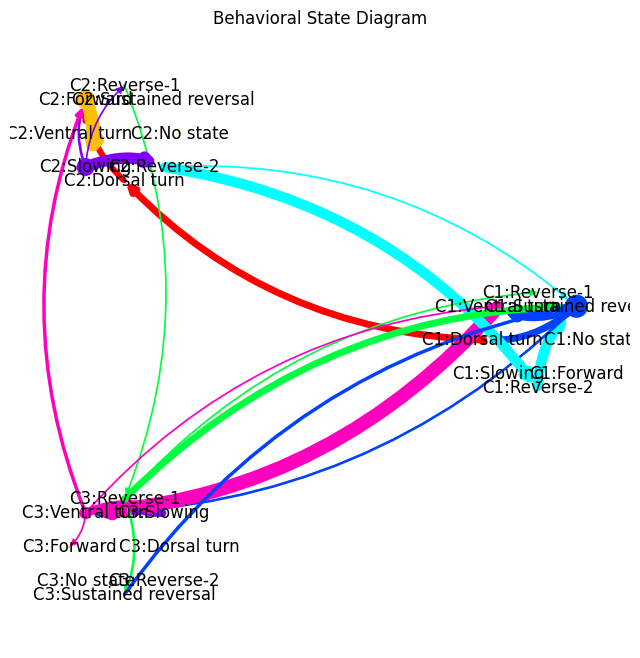

Calculated threshold is:  0.000512656199935918


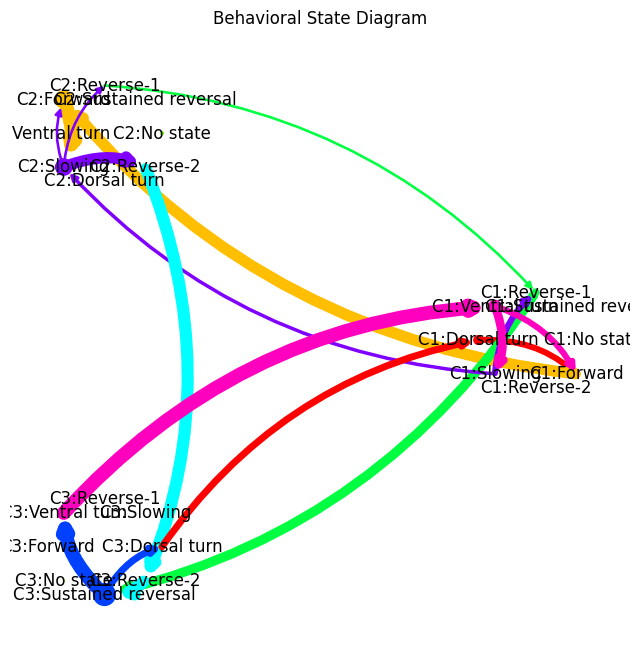

True

In [46]:
behavioral_state_diagram(
    best_sequence_r, b,
    behaviors=behaviors,
    offset=5,
    figsize=(8, 8)
)
behavioral_state_diagram(
    best_sequence_e, b_,
    behaviors=behaviors,
    offset=5,
    figsize=(8, 8)
)

Calculated threshold is:  0.000510204081632653


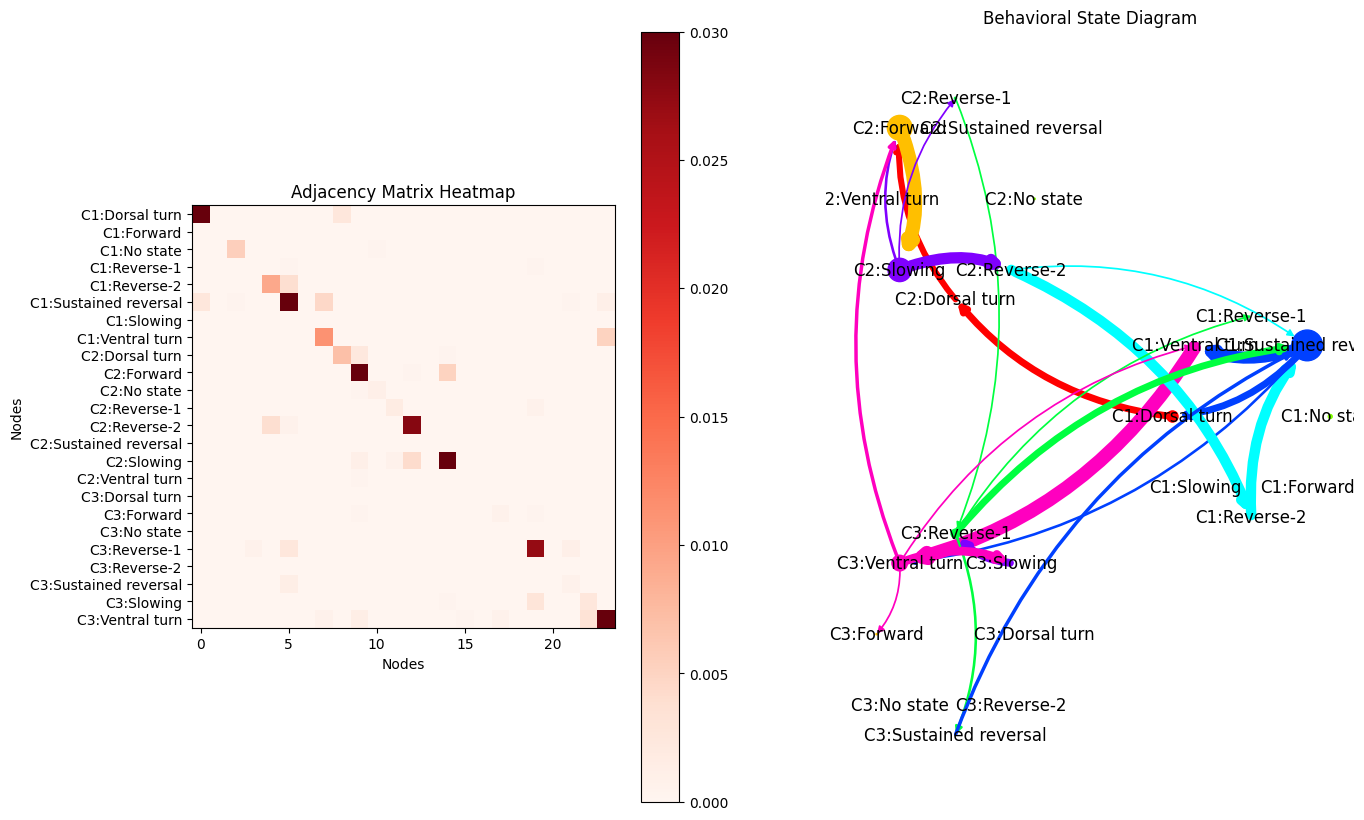

Calculated threshold is:  0.000512656199935918


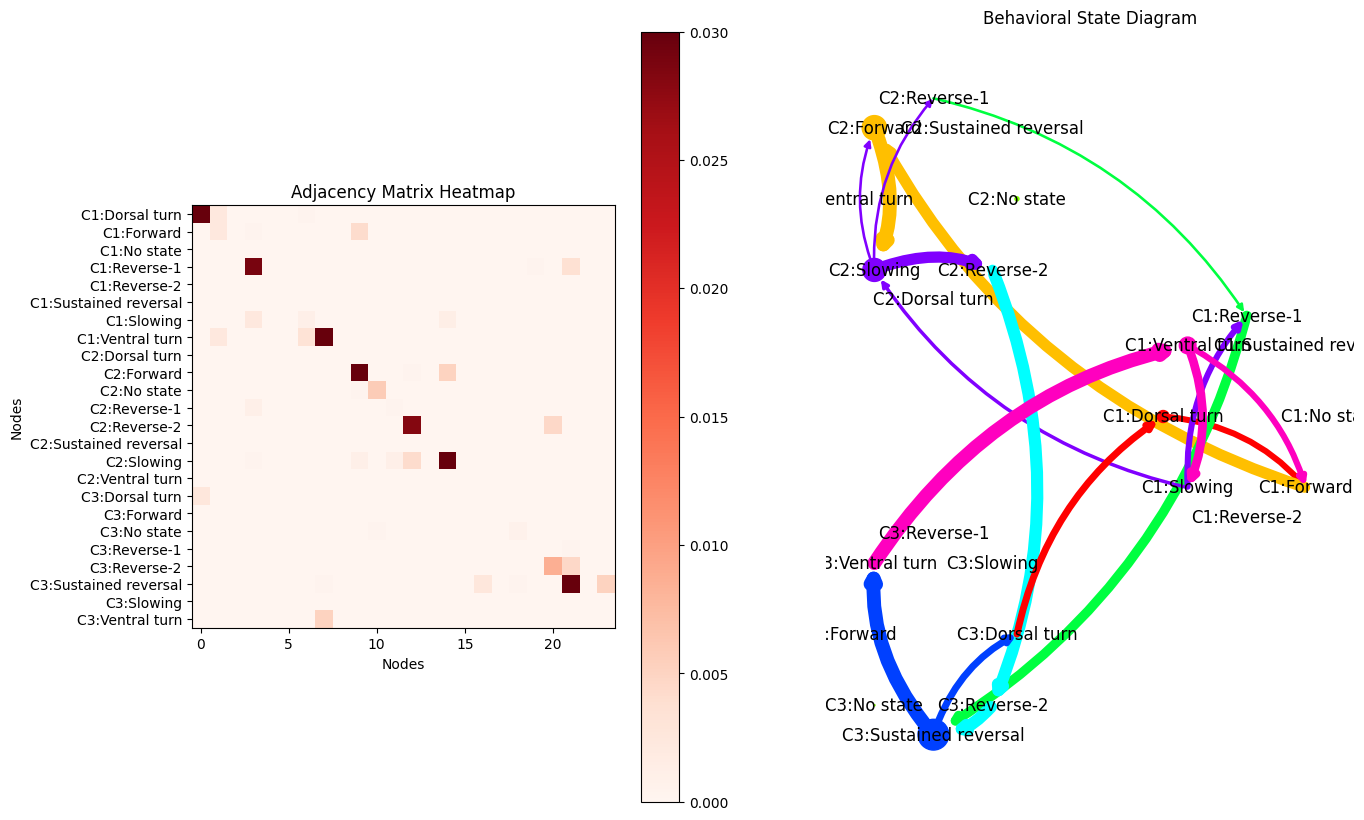

True

In [47]:
# Next we also plot the adjacency matrix
behavioral_state_diagram(
    best_sequence_r, b,
    behaviors=behaviors,
    adj_matrix=True,
    figsize=(15, 10)
)
behavioral_state_diagram(
    best_sequence_e, b_,
    behaviors=behaviors,
    adj_matrix=True,
    figsize=(15, 10)
)